In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from skimage.morphology import disk
from scipy.signal.windows import hann
from quantem.core.visualization.custom_normalizations import NormalizationConfig
from matplotlib.patches import Rectangle
from scipy.signal import fftconvolve
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography
import numpy as np
from scipy.signal import fftconvolve
from scipy.ndimage import maximum_filter, label, find_objects
from scipy.ndimage import shift
from scipy.ndimage import zoom
from skimage.registration import phase_cross_correlation

def crop_white_border(rgba):
    # Convert to grayscale and find non-white rows/cols
    gray = rgba[..., :3].mean(axis=2)
    mask = gray < 255
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rgba[rmin:rmax+1, cmin:cmax+1]
from scipy.ndimage import shift as nd_shift

from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")


from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

import abtem
import ase
import logging
logging.getLogger("hyperspy").setLevel(logging.ERROR)
def cmplx_array_to_rgba(cmplx_valued_array, vmin=0.02, vmax=0.98):
    scaled_amplitude = np.abs(cmplx_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = np.angle(cmplx_valued_array)
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
    return rgba

def real_array_to_rgba(real_valued_array, vmin=0.02, vmax=0.98, cmap='gray'):
    scaled_amplitude = np.abs(real_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = None
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase, cmap=cmap)
    return rgba

from abtem.core.energy import energy2sigma

def subpixel_shift(img, shift):
    """
    Circularly shift a 2D (or 3D with leading singleton) array by a
    sub-pixel amount using the Fourier shift theorem.
    shift: (dy, dx) in pixels, applied along the last two axes.
    Positive dx shifts content to the right (same convention as np.roll).
    """
    dy, dx = shift
    *_, ny, nx = img.shape
    
    F = np.fft.fft2(img, axes=(-2, -1))
    
    ky = np.fft.fftfreq(ny)[:, None]
    kx = np.fft.fftfreq(nx)[None, :]
    
    phase_ramp = np.exp(-2j * np.pi * (ky * dy + kx * dx))
    
    F_shifted = F * phase_ramp
    shifted = np.fft.ifft2(F_shifted, axes=(-2, -1))
    
    # if the input was real, the output should be too (up to numerical noise)
    if np.isrealobj(img):
        shifted = shifted.real
    
    return shifted

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

def compute_global_shift_xcorr(img_ref, img_target, upsample_factor=20):
    """
    Compute the global (row_shift, col_shift) i.e. (dy, dx) that best
    aligns img_target to img_ref, using Fourier-based phase cross-correlation.

    Parameters
    ----------
    img_ref : reference image (e.g. gt_image)
    img_target : image to register against the reference (e.g. phase)
    upsample_factor : controls sub-pixel precision (20 -> 1/20 px precision)

    Returns
    -------
    shift : (dy, dx) — apply as target_shifted = shift(img_target, shift) to align it to img_ref
    error : normalized RMS registration error
    diffphase : global phase difference (usually irrelevant here)
    """
    shift, error, diffphase = phase_cross_correlation(
        img_ref, img_target, upsample_factor=upsample_factor, normalization='phase'
    )
    return shift, error, diffphase

quantEM version: 0.1.8


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
convergence_angle = 6
gpts = 64
force_com_rotation = 0
batch_size = 8
device = "cuda:1"
num_iters = 30
reset = True
d = 20
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = False


# -----------------------------
# Load upper/lower CSVs
# -----------------------------
dfs = []

for particle in ["upper", "lower"]:
    results_dir = f"two_particles_results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"

    csv_path = os.path.join(
        results_dir,
        f"shifts_conv{convergence_angle}"
        f"_batchsize{batch_size}"
        f"_iters{num_iters}"
        f"_gpts{gpts}_{particle}.csv"
    )
    df = pd.read_csv(csv_path)

    # csv_path = f'results_conv28_batchsize512_iters125_gpts128_2particles_d20_dose1.0e+15_large_fov2/shifts_conv28_batchsize512_iters125_gpts128_{particle}.csv'
    # csv_path = f'results_conv22_batchsize8_iters30_gpts128_2particles_d20_dose1.0e+07_large_fov2/shifts_conv22_batchsize8_iters30_gpts128_{particle}.csv'
    # csv_path = f'results_conv14_batchsize8_iters30_gpts128_2particles_d20_dose1.0e+05_large_fov2/shifts_conv14_batchsize8_iters30_gpts128_{particle}.csv'

    df = pd.read_csv(csv_path)
    df["particle"] = particle
    df["convergence_angle"] = convergence_angle


    if particle == 'lower':
        correction_x = 0.2
        correction_y = 0.3
        # derived quantities
        df["shift_amplitude"] = np.sqrt((df["shift_x_0"]+correction_x)**2 + (df["shift_y_0"]+correction_y)**2)
        df["shift_angle"] = np.degrees(np.arctan2(df["shift_y_0"]+correction_y, df["shift_x_0"]+correction_x))
        # df["shift_amplitude"] = np.sqrt(df["shift_x"]**2 + df["shift_y"]**2)
        # df["shift_angle"] = np.degrees(np.arctan2(df["shift_y"], df["shift_x"]))
    else:
        correction_x = 0.15
        correction_y = 0.1
        df["shift_amplitude"] = np.sqrt((df["shift_x_0"]+correction_x)**2 + (df["shift_y_0"]+correction_y)**2)
        df["shift_angle"] = np.degrees(np.arctan2(df["shift_y_0"]+correction_y, df["shift_x_0"]+correction_x))
    dfs.append(df)


dataset = pd.concat(dfs, ignore_index=True)
# dataset = dataset[dataset.particle=='lower']


print(dataset.head())


   rngi  shift_x  shift_y  ncc_peak  shift_x_0  shift_y_0  registration_error  \
0     0     0.98    16.94  0.810073   0.562855   0.582469            0.999999   
1     1    -0.04    -0.32  0.851751  -0.159768  -0.328082            0.999997   
2     2     0.02    -1.12  0.904863   0.037521  -1.278246            0.999989   
3     3     1.02    -0.06  0.921890   0.807428  -0.037318            0.999990   
4     4     0.06    -0.16  0.859036   0.351566  -0.182407            0.999995   

  particle  convergence_angle  shift_amplitude  shift_angle  
0    upper                  6         0.986877    43.752468  
1    upper                  6         0.228291   -92.452338  
2    upper                  6         1.193075   -80.957072  
3    upper                  6         0.959478     3.745743  
4    upper                  6         0.508291    -9.330295  


Saved to two_particles_results_conv6_d20_gpts64_dose1.0e+15_batchsize8_iters30_pixels256_on_aCFalse/shift_amplitude_conv6_d20_gpts64_dose1.0e+15_batchsize8_iters30_pixels256.png


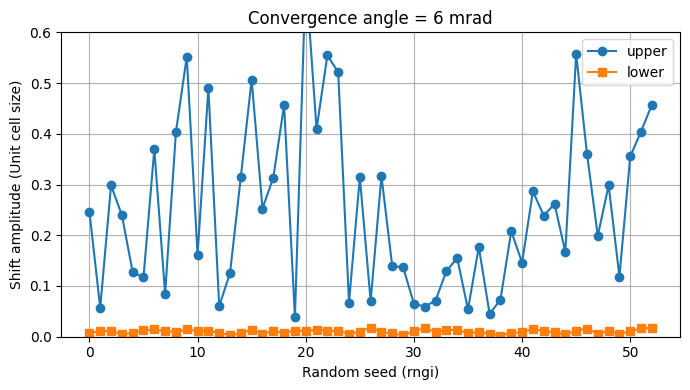

In [4]:
fig, ax = plt.subplots(figsize=(7,4))

for particle, marker in zip(["upper", "lower"], ["o", "s"]):
    sub = dataset[dataset["particle"] == particle].sort_values("rngi")

    ax.plot(
        sub["rngi"],
        sub["shift_amplitude"]/(4*pixels_in_diff_pattern/256),
        marker=marker,
        label=particle,
    )

ax.set_xlabel("Random seed (rngi)")
ax.set_ylabel("Shift amplitude (Unit cell size)")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.grid(True)
ax.legend()
ax.set_ylim(0,0.6)

plt.tight_layout()

save_path = os.path.join(
    results_dir,
    f"shift_amplitude_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}"
    f"_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}.png"
)
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to {save_path}")

plt.show()

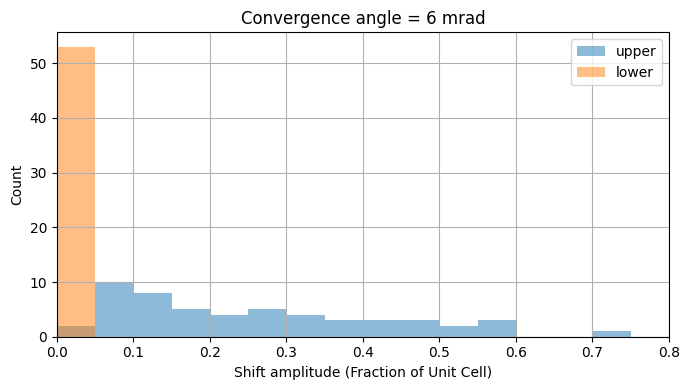

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.arange(0, 0.81, 0.05)  # 0.0, 0.1, ..., 0.6

for particle in ["upper", "lower"]:
    sub = dataset[dataset["particle"] == particle]

    values = sub["shift_amplitude"] / (4 * pixels_in_diff_pattern / 256)

    ax.hist(
        values,
        bins=bins,
        alpha=0.5,
        label=particle,
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Count")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.set_xlim(0, 0.8)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

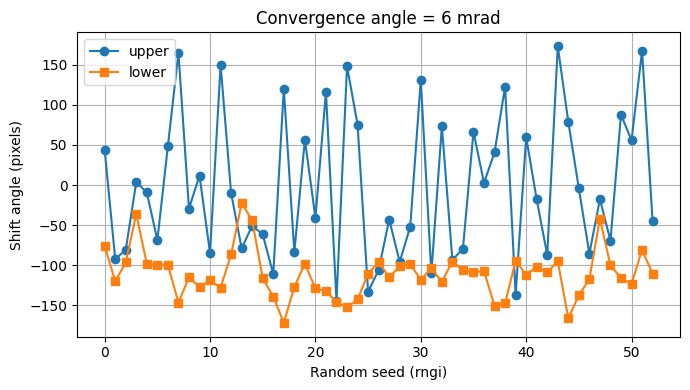

In [7]:
fig, ax = plt.subplots(figsize=(7,4))

for particle, marker in zip(["upper", "lower"], ["o", "s"]):
    sub = dataset[dataset["particle"] == particle].sort_values("rngi")

    ax.plot(
        sub["rngi"],
        sub["shift_angle"],
        marker=marker,
        label=particle,
    )

ax.set_xlabel("Random seed (rngi)")
ax.set_ylabel("Shift angle (pixels)")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.grid(True)
ax.legend()
# ax.set_ylim(0,5)

plt.tight_layout()
plt.show()

all_data_no_aC keys: [1.5]
0    0.032012
Name: shift_amplitude, dtype: float64


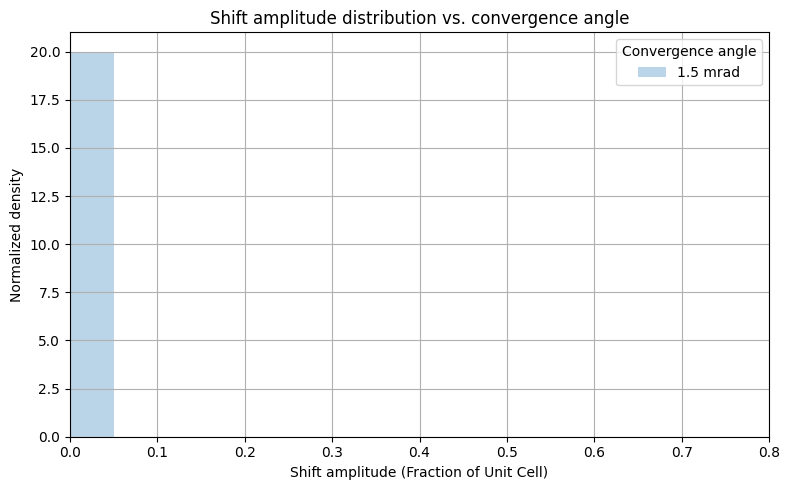

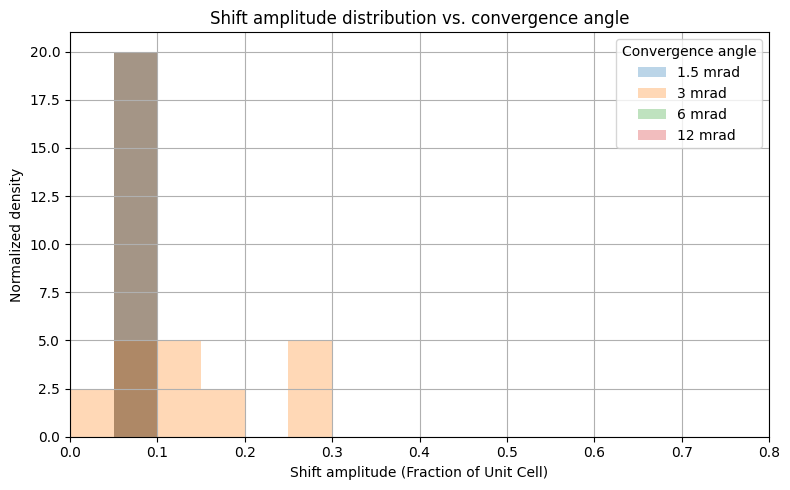

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings (everything except convergence_angle stays fixed)
# -----------------------------
convergence_angle = 6
gpts = 64
force_com_rotation = 0
batch_size = 8
device = "cuda:1"
num_iters = 30
reset = True
d = 20
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = True

convergence_angles = [1.5]

def load_dataset(convergence_angle):
    dfs = []
    for particle in ["upper", "lower"]:
        results_dir = f"two_particles_results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"

        csv_path = os.path.join(
            results_dir,
            f"shifts_conv{convergence_angle}_batchsize{batch_size}"
            f"_iters{num_iters}_gpts{gpts}_{particle}.csv"
        )
        df = pd.read_csv(csv_path)
        df["particle"] = particle
        df["convergence_angle"] = convergence_angle

        if particle == "lower":
            correction_x = 0#.2
            correction_y = 0#.3        
        else:
            correction_x = 0#.15
            correction_y = 0#.1
        df["shift_amplitude"] = np.sqrt(
            (df["shift_x_0"] + correction_x) ** 2 + (df["shift_y_0"] + correction_y) ** 2
        )
        df["shift_angle"] = np.degrees(
            np.arctan2(df["shift_y_0"] + correction_y, df["shift_x_0"] + correction_x)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# -----------------------------
# Load all datasets
# -----------------------------
all_data_no_aC = {ca: load_dataset(ca) for ca in convergence_angles}
print(f'all_data_no_aC keys: {list(all_data_no_aC.keys())}')

# -----------------------------
# Plot normalized histograms for all convergence angles
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particle_to_plot = "upper"

for ca in convergence_angles:
    dataset_no_aC = all_data_no_aC[ca]
    sub_no_aC = dataset_no_aC[dataset_no_aC["particle"] == particle_to_plot]

    values_no_aC = sub_no_aC["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)
    print(values_no_aC)

    ax.hist(
        values_no_aC,
        bins=bins,
        alpha=0.3,
        density=True,      # <-- normalizes so area under each histogram = 1
        label=f"{ca} mrad",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Normalized density")
ax.set_title("Shift amplitude distribution vs. convergence angle")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle")
ax.grid(True)

plt.tight_layout()
plt.show()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings (everything except convergence_angle stays fixed)
# -----------------------------
convergence_angle = 6
gpts = 64
force_com_rotation = 0
batch_size = 8
device = "cuda:1"
num_iters = 30
reset = True
d = 20
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = True

convergence_angles = [1.5, 3, 6, 12]

# -----------------------------
# Load all datasets
# -----------------------------
all_data_with_aC = {ca: load_dataset(ca) for ca in convergence_angles}


# -----------------------------
# Plot normalized histograms for all convergence angles
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particle_to_plot = "lower"

for ca in convergence_angles:
    dataset_with_aC = all_data_with_aC[ca]
    sub_with_aC = dataset_with_aC[dataset_with_aC["particle"] == particle_to_plot]

    values_with_aC = sub_with_aC["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

    ax.hist(
        values_with_aC,
        bins=bins,
        alpha=0.3,
        density=True,      # <-- normalizes so area under each histogram = 1
        label=f"{ca} mrad",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Normalized density")
ax.set_title("Shift amplitude distribution vs. convergence angle")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle")
ax.grid(True)

plt.tight_layout()
plt.show()

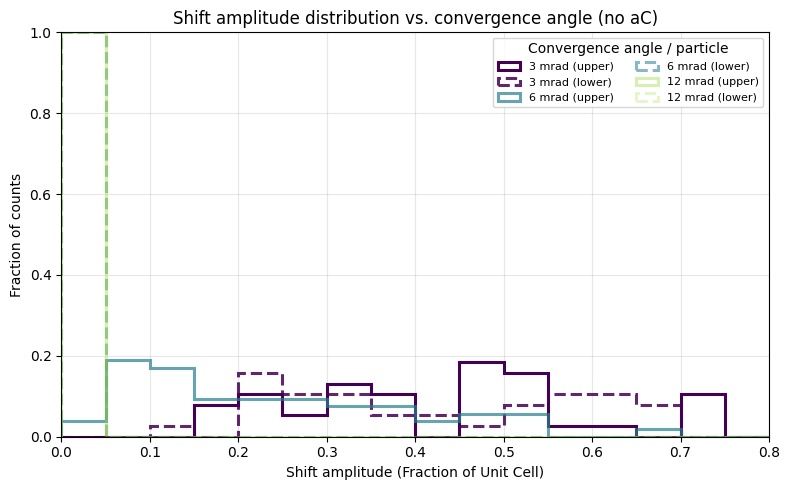

In [12]:
import numpy as np
import matplotlib.pyplot as plt
convergence_angle = 6
gpts = 64
force_com_rotation = 0
batch_size = 8
device = "cuda:1"
num_iters = 30
reset = True
d = 20
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = False
def load_dataset(convergence_angle):
    dfs = []
    for particle in ["upper", "lower"]:
        results_dir = f"two_particles_results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"

        csv_path = os.path.join(
            results_dir,
            f"shifts_conv{convergence_angle}_batchsize{batch_size}"
            f"_iters{num_iters}_gpts{gpts}_{particle}.csv"
        )
        df = pd.read_csv(csv_path)
        df["particle"] = particle
        df["convergence_angle"] = convergence_angle

        if particle == "lower":
            correction_x = 0.2
            correction_y = 0.3        
        else:
            correction_x = 0.15
            correction_y = 0.1
        df["shift_amplitude"] = np.sqrt(
            (df["shift_x_0"] + correction_x) ** 2 + (df["shift_y_0"] + correction_y) ** 2
        )
        df["shift_angle"] = np.degrees(
            np.arctan2(df["shift_y_0"] + correction_y, df["shift_x_0"] + correction_x)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)
convergence_angles = [3, 6, 12]
particles = ["upper", "lower"]

all_data = {ca: load_dataset(ca) for ca in convergence_angles}

bins = np.arange(0, 0.81, 0.05)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_series = len(convergence_angles) * len(particles)
bar_width = (bins[1] - bins[0]) / (n_series + 1)  # leave a small gap between groups

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particles = ["upper", "lower"]

colors = plt.cm.viridis(np.linspace(0, 0.85, len(convergence_angles)))
count = 0
for ca, color in zip(convergence_angles, colors):
    dataset = all_data[ca]
    for particle, linestyle in zip(particles, ["-", "--"]):
        sub = dataset[dataset["particle"] == particle]
        values = sub["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

        weights = np.ones_like(values) / len(values)  # each series sums to 1
        alpha = 1 - count*0.15
        ax.hist(
            values,
            bins=bins,
            weights=weights,
            histtype="step",
            linewidth=2.2,
            linestyle=linestyle,
            color=color,
            alpha=alpha,
            label=f"{ca} mrad ({particle})",
        )
        count += 1

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Fraction of counts")
ax.set_ylim(0, 1)
ax.set_title("Shift amplitude distribution vs. convergence angle (no aC)")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle / particle", ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

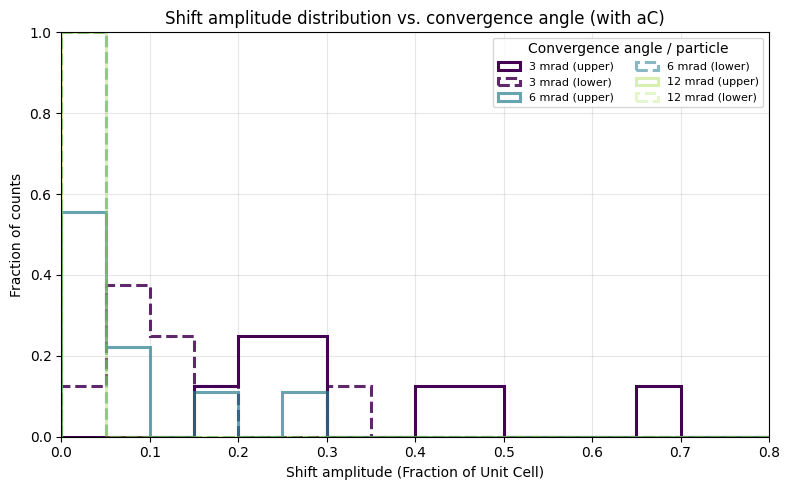

In [16]:
import numpy as np
import matplotlib.pyplot as plt
convergence_angle = 6
gpts = 64
force_com_rotation = 0
batch_size = 8
device = "cuda:1"
num_iters = 30
reset = True
d = 20
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = True
def load_dataset(convergence_angle):
    dfs = []
    for particle in ["upper", "lower"]:
        results_dir = f"two_particles_results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"

        csv_path = os.path.join(
            results_dir,
            f"shifts_conv{convergence_angle}_batchsize{batch_size}"
            f"_iters{num_iters}_gpts{gpts}_{particle}.csv"
        )
        df = pd.read_csv(csv_path)
        df["particle"] = particle
        df["convergence_angle"] = convergence_angle

        if particle == "lower":
            correction_x = 0.2
            correction_y = 0.3        
        else:
            correction_x = 0.15
            correction_y = 0.1
        df["shift_amplitude"] = np.sqrt(
            (df["shift_x_0"] + correction_x) ** 2 + (df["shift_y_0"] + correction_y) ** 2
        )
        df["shift_angle"] = np.degrees(
            np.arctan2(df["shift_y_0"] + correction_y, df["shift_x_0"] + correction_x)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)
convergence_angles = [3, 6, 12]
particles = ["upper", "lower"]

all_data = {ca: load_dataset(ca) for ca in convergence_angles}

bins = np.arange(0, 0.81, 0.05)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_series = len(convergence_angles) * len(particles)
bar_width = (bins[1] - bins[0]) / (n_series + 1)  # leave a small gap between groups

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particles = ["upper", "lower"]

colors = plt.cm.viridis(np.linspace(0, 0.85, len(convergence_angles)))
count = 0
for ca, color in zip(convergence_angles, colors):
    dataset = all_data[ca]
    for particle, linestyle in zip(particles, ["-", "--"]):
        sub = dataset[dataset["particle"] == particle]
        values = sub["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

        weights = np.ones_like(values) / len(values)  # each series sums to 1
        alpha = 1 - count*0.15
        ax.hist(
            values,
            bins=bins,
            weights=weights,
            histtype="step",
            linewidth=2.2,
            linestyle=linestyle,
            color=color,
            alpha=alpha,
            label=f"{ca} mrad ({particle})",
        )
        count += 1

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Fraction of counts")
ax.set_ylim(0, 1)
ax.set_title("Shift amplitude distribution vs. convergence angle (with aC)")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle / particle", ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()